In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix,roc_curve, auc
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
%matplotlib inline

In [36]:
df = pd.read_csv('hotel_bookings.csv')
print(df.shape)
df.head()

(119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


# Data Card: Hotel Bookings Dataset

## **Dataset Overview**
- **Name**: Hotel Booking Demand Dataset
- **Source**: Kaggle (jessemostajo/hotel-booking-demand)
- **Format**: Single CSV file (Flat Sheet)
- **Rows**: 119,390
- **Columns**: 32
- **Time Period**: 2015 – 2017
- **Target Variable**: `is_canceled` (Binary: 0 = Not Canceled, 1 = Canceled)

**Cancellation Rate**: 37.04% (44,224 canceled bookings)

---

## **Business Objective**
Audit revenue leakage caused by cancellations and identify high-risk booking profiles to support revenue optimization strategies.

---

## **Key Columns Description**

| Category              | Column                          | Description                                      | Type       | Notes |
|-----------------------|---------------------------------|--------------------------------------------------|------------|-------|
| **Hotel**             | `hotel`                         | Hotel type (Resort Hotel / City Hotel)           | Categorical | - |
| **Target**            | `is_canceled`                   | Booking canceled or not                          | Binary     | **Target** |
| **Booking**           | `lead_time`                     | Days between booking and arrival                 | Numeric    | High values = higher risk |
| **Arrival**           | `arrival_date_year/month/day`   | Arrival date components                          | Numeric/Cat| Combined into datetime |
| **Stay**              | `stays_in_weekend_nights`       | Number of weekend nights                         | Numeric    | - |
| **Stay**              | `stays_in_week_nights`          | Number of week nights                            | Numeric    | - |
| **Guests**            | `adults`, `children`, `babies`  | Number of guests                                 | Numeric    | Ghost guests exist |
| **Meal**              | `meal`                          | Meal package (BB, HB, FB, SC)                    | Categorical | - |
| **Country**           | `country`                       | Country of origin                                | Categorical | High cardinality |
| **Market**            | `market_segment`                | Market segment (Online TA, Offline TA, etc.)     | Categorical | - |
| **Channel**           | `distribution_channel`          | Booking channel (TA/TO, Direct, Corporate)       | Categorical | Key revenue driver |
| **Room**              | `reserved_room_type` / `assigned_room_type` | Room type reserved vs assigned | Categorical | Discrepancies exist |
| **Deposit**           | `deposit_type`                  | Deposit policy (No Deposit, Non Refund, Refundable) | Categorical | Strong cancellation predictor |
| **Customer**          | `customer_type`                 | Transient, Contract, Group, Transient-Party      | Categorical | - |
| **Financial**         | `adr`                           | Average Daily Rate                               | Numeric    | Revenue per night |
| **Other**             | `previous_cancellations`, `booking_changes`, `total_of_special_requests` | Historical behavior | Numeric | - |

---

## **Data Quality Highlights (Phase 1 Findings)**

- **Ghost Guests**: ~180 bookings where `adults + children + babies = 0`
- **Zero/Negative ADR** (Non-canceled): Present — may represent complimentary stays or data errors
- **Missing Values**: `children`, `country`, `agent`, `company`
- **High Cardinality**: `country`, `agent`, `company`

---

## **Class Distribution**
- **Not Canceled** (0): 75,166 (62.96%)
- **Canceled** (1): 44,224 (37.04%)

---
**Data Card Prepared for**: Hotel Revenue Leakage Audit  

# Phase 1: Data Integrity & Inconsistency Sanity Audit

## Executive Summary
A thorough data quality audit was conducted to identify structural issues that could distort revenue leakage analysis. Addressing these inconsistencies is critical for accurate financial insights and strategic decision-making.

---

### 1. Ghost Guest Audit

**Definition**: Bookings where the composite sum of guests equals zero (`adults + children + babies == 0`).

**Findings**:
- **Total Ghost Guests**: **180**
- **Percentage of Dataset**: **0.15%**

**Business Impact**:
- These phantom bookings artificially inflate occupancy and booking numbers without generating any actual revenue.
- They distort key performance metrics such as Average Daily Rate (ADR), Revenue Per Available Room (RevPAR), and cancellation rates.
- Operational resources (staffing, inventory planning) may be misallocated based on inaccurate demand signals.

**Recommendation**: Filter out these records before final analysis and investigate root causes in the booking system.

---

### 2. Financial Anomaly Extraction

**Definition**: Survived bookings (`is_canceled == 0`) with zero or negative `adr`.

**Findings**:
- **Total Anomalies**: **1,747**
- Includes zero ADR and a small number of negative values.

**Business Impact**:
- Understates true revenue potential and distorts profitability analysis.
- If these represent unrecorded complimentary stays, they indicate hidden costs not captured in revenue reporting.
- Negative ADR values suggest possible data entry errors or system bugs that could lead to incorrect financial statements.

**Recommendation**: Flag for review by Revenue Management and Finance teams. Consider imputing realistic ADR based on room type, season, and channel where appropriate.

---

### 3. Temporal Feature Aggregation

**Definition**: Merging `arrival_date_year`, `arrival_date_month`, and `arrival_date_day_of_month` into a single unified datetime column.

**Implementation**:
- Created `arrival_date_month_num` using month mapping.
- Combined components using `pd.to_datetime()`.

**Result**:
- **New Column**: `arrival_date`
- **Date Range**: July 1, 2015 – August 31, 2017

**Business Impact**:
- Enables accurate time-series analysis, seasonality detection, and trend identification.
- Critical for forecasting demand, implementing dynamic pricing, and planning promotional campaigns.
- Without this, temporal patterns (e.g., peak cancellation periods) would remain hidden, limiting proactive revenue protection strategies.

---

## Phase 1 Key Takeaways & Recommendations

- **Overall Data Quality**: Moderate issues identified (≈1,927 problematic rows).
- These integrity problems, if left unaddressed, can lead to misguided strategic decisions and significant revenue misreporting.
- **Actionable Insight**: Clean the dataset by handling ghost guests and anomalies before proceeding to modeling and financial exposure calculations.

**Data is now prepared** for reliable bivariate, multivariate, and financial leakage analysis in subsequent phases.

---

In [37]:
df['total_guests'] = df['adults'] + df['children'].fillna(0) + df['babies'].fillna(0)
ghost_guests = df[df['total_guests'] == 0]
print(f'Ghost bookings: {len(ghost_guests)} ({len(ghost_guests)/len(df)*100:.2f}%)')
print(ghost_guests['is_canceled'].value_counts())

Ghost bookings: 180 (0.15%)
is_canceled
0    155
1     25
Name: count, dtype: int64


In [38]:
anomalies = df[(df['is_canceled'] == 0) & (df['adr'] <= 0)]
print(f'Non-canceled bookings with ADR <=0: {len(anomalies)}')
print(anomalies['adr'].describe())

Non-canceled bookings with ADR <=0: 1747
count    1747.000000
mean       -0.003652
std         0.152642
min        -6.380000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.000000
Name: adr, dtype: float64


In [54]:
print("=== TEMPORAL FEATURE AGGREGATION ===")
df['arrival_date_month_num'] = df['arrival_date_month'].map({
    'January':1, 'February':2, 'March':3, 'April':4, 'May':5, 'June':6,
    'July':7, 'August':8, 'September':9, 'October':10, 'November':11, 'December':12
})
df['arrival_date'] = pd.to_datetime(
    df['arrival_date_year'].astype(str) + '-' + 
    df['arrival_date_month_num'].astype(str).str.zfill(2) + '-' + 
    df['arrival_date_day_of_month'].astype(str).str.zfill(2)
)
print("✅ Unified 'arrival_date' column created successfully!")
print(f"Date Range: {df['arrival_date'].min()} to {df['arrival_date'].max()}")
print(df[['arrival_date_year', 'arrival_date_month', 'arrival_date_day_of_month', 'arrival_date']].head())

=== TEMPORAL FEATURE AGGREGATION ===
✅ Unified 'arrival_date' column created successfully!
Date Range: 2015-07-01 00:00:00 to 2017-08-31 00:00:00
   arrival_date_year arrival_date_month  arrival_date_day_of_month  \
0               2015               July                          1   
1               2015               July                          1   
2               2015               July                          1   
3               2015               July                          1   
4               2015               July                          1   

  arrival_date  
0   2015-07-01  
1   2015-07-01  
2   2015-07-01  
3   2015-07-01  
4   2015-07-01  


deposit_type
No Deposit    28.377022
Non Refund    99.362446
Refundable    22.222222
Name: is_canceled, dtype: float64


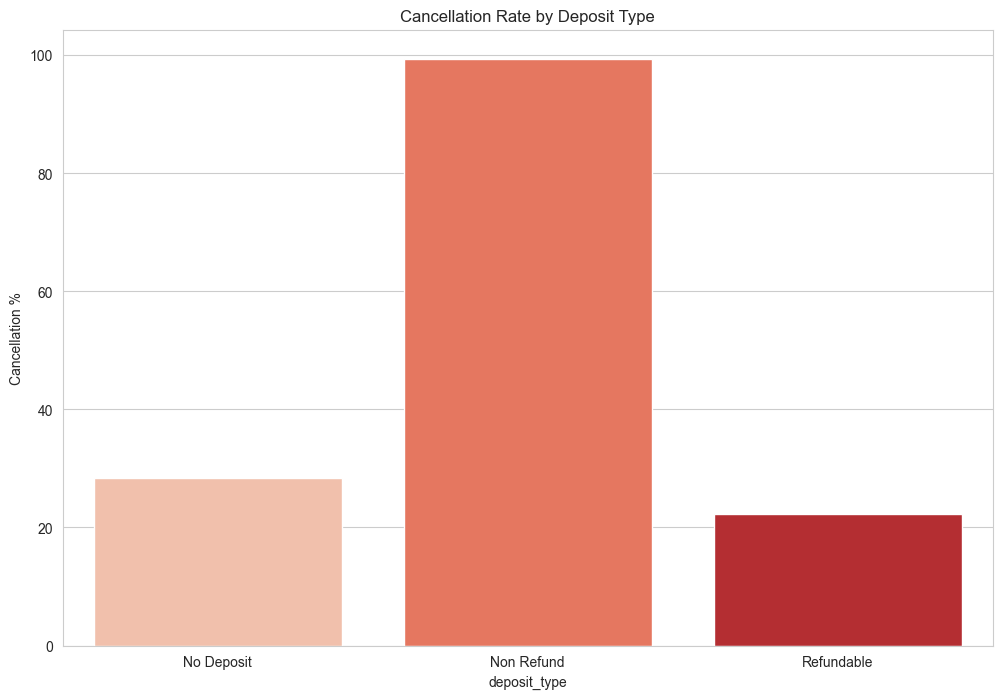

In [40]:
cancel_by_deposit = df.groupby('deposit_type')['is_canceled'].mean() * 100
print(cancel_by_deposit)
plt.figure()
sns.barplot(x=cancel_by_deposit.index, y=cancel_by_deposit.values, palette='Reds')
plt.title('Cancellation Rate by Deposit Type')
plt.ylabel('Cancellation %')
plt.show()

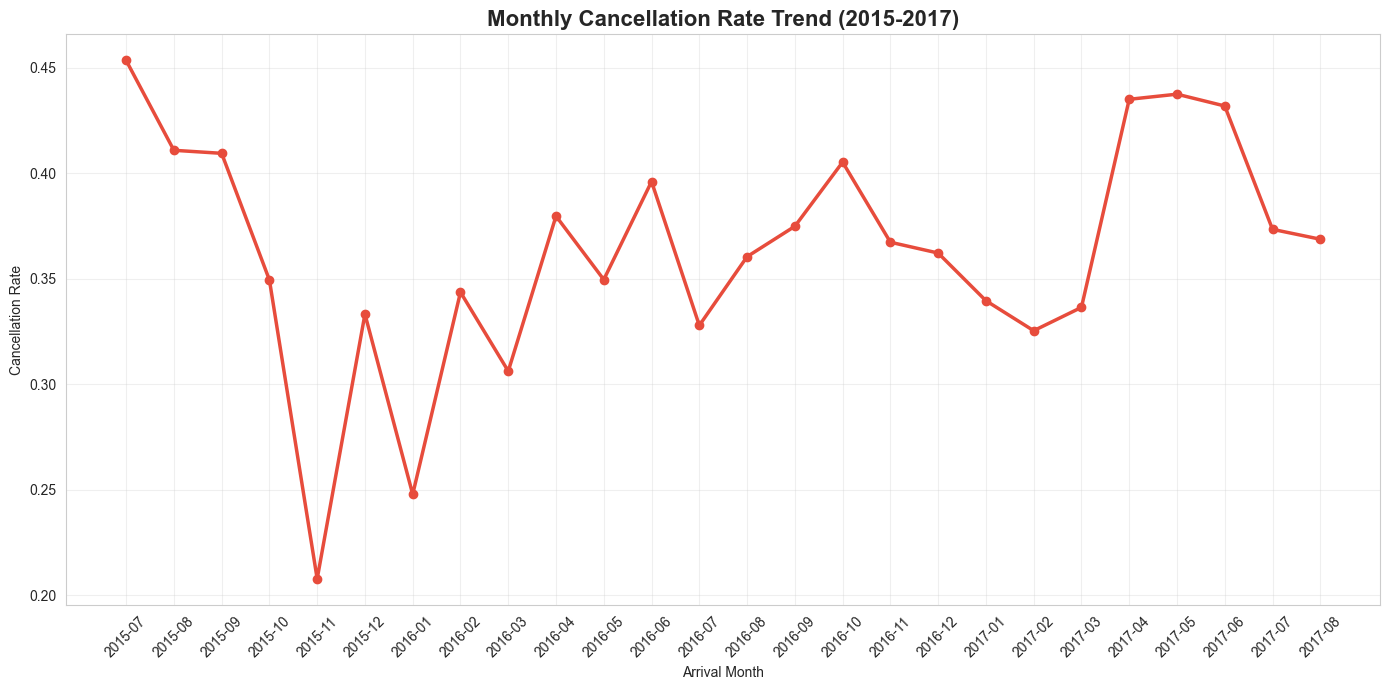

In [55]:
monthly_trend = df.groupby(df['arrival_date'].dt.to_period('M')).agg(
    total_bookings=('is_canceled', 'count'),
    canceled=('is_canceled', 'sum')
).reset_index()
monthly_trend['cancellation_rate'] = monthly_trend['canceled'] / monthly_trend['total_bookings']
plt.figure(figsize=(14, 7))
plt.plot(monthly_trend['arrival_date'].astype(str), monthly_trend['cancellation_rate'], 
         marker='o', linewidth=2.5, color='#e74c3c')
plt.title('Monthly Cancellation Rate Trend (2015-2017)', fontsize=16, fontweight='bold')
plt.xlabel('Arrival Month')
plt.ylabel('Cancellation Rate')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Monthly Cancellation Rate Trend Analysis

### Why Analyze Monthly Cancellation Trends?

Understanding how cancellation rates change over time is essential for identifying seasonal patterns, operational challenges, and customer booking behavior.

Hotels often experience fluctuations in cancellations due to factors such as:

- Seasonal demand changes
- Holiday periods
- Economic conditions
- Pricing strategies
- Travel trends

### What Does This Analysis Do?

This analysis groups hotel bookings by arrival month and calculates:

- Total Bookings
- Total Cancellations
- Monthly Cancellation Rate

The cancellation rate is calculated as:

Cancellation Rate = Number of Cancelled Bookings / Total Bookings

### Why Use a Line Chart?

A line chart is ideal for time-series analysis because it clearly shows trends, patterns, peaks, and declines over multiple months.

### Business Objective

The objective is to identify periods with unusually high cancellation rates so that hotel management can:

- Improve revenue forecasting
- Optimize room inventory management
- Adjust cancellation policies
- Develop targeted retention strategies

### Expected Insight

The visualization helps determine whether cancellation behavior follows a consistent pattern or if specific months experience significantly higher cancellation rates than others.

### Executive Takeaway

The monthly cancellation trend provides valuable insight into customer booking behavior over time.

Months with elevated cancellation rates may indicate seasonal effects, pricing issues, or external factors influencing customer decisions. Understanding these trends enables hotel management to proactively adjust operational and revenue management strategies.

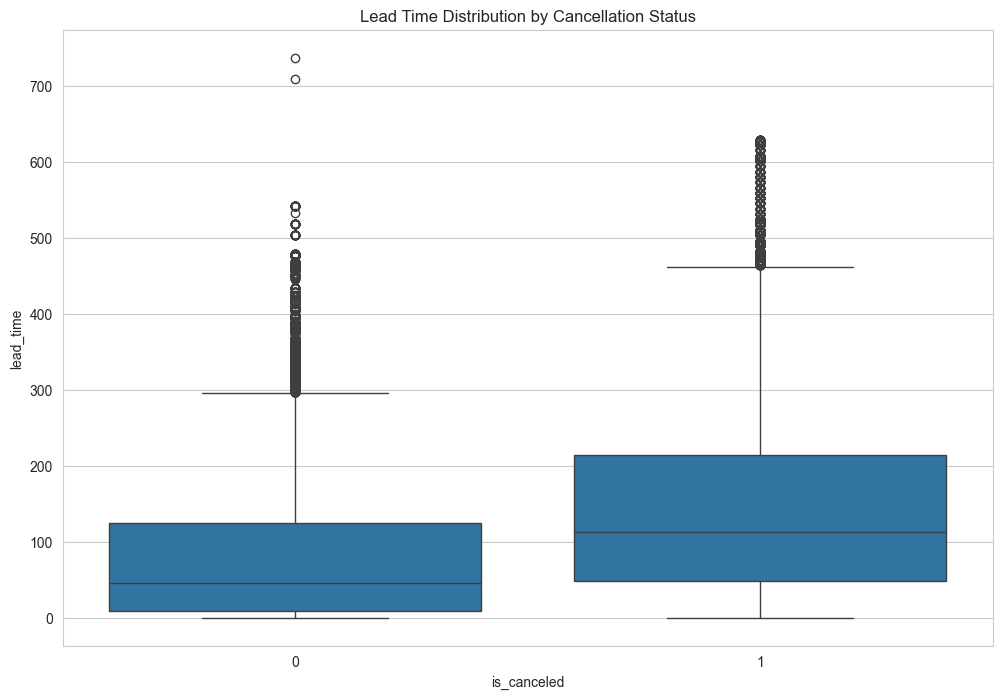

Mean lead_time canceled: 144.84881512301013
Mean lead_time not canceled: 79.98468722560732


In [41]:
plt.figure()
sns.boxplot(x='is_canceled', y='lead_time', data=df)
plt.title('Lead Time Distribution by Cancellation Status')
plt.show()
print('Mean lead_time canceled:', df[df['is_canceled']==1]['lead_time'].mean())
print('Mean lead_time not canceled:', df[df['is_canceled']==0]['lead_time'].mean())

### Observation

- The boxplot indicates a noticeable difference in lead time between cancelled and non-cancelled bookings.
- Customers who cancelled their reservations tend to have a higher average lead time compared to customers who completed their stay.
- This suggests that bookings made well in advance are more susceptible to cancellation due to changes in travel plans or customer preferences.
- The presence of outliers indicates that some reservations were booked extremely early and later cancelled.

### Business Impact

- Higher lead times are associated with an increased risk of cancellation, making lead time a critical predictor for cancellation analysis.
- Hotels may face revenue uncertainty when a large proportion of bookings are made far in advance.
- Implementing stricter cancellation policies or advance deposits for long lead-time bookings can help reduce financial losses.
- Understanding this pattern enables better inventory management, demand forecasting, and overbooking strategies to maximize occupancy and revenue.

=== CUSTOMER SEGMENT VOLATILITY ANALYSIS ===
                 Not Canceled  Canceled  total_bookings  cancellation_rate
customer_type                                                             
Transient              0.5925    0.4075           89613             0.4075
Contract               0.6904    0.3096            4076             0.3096
Transient-Party        0.7457    0.2543           25124             0.2543
Group                  0.8977    0.1023             577             0.1023


<Figure size 1000x700 with 0 Axes>

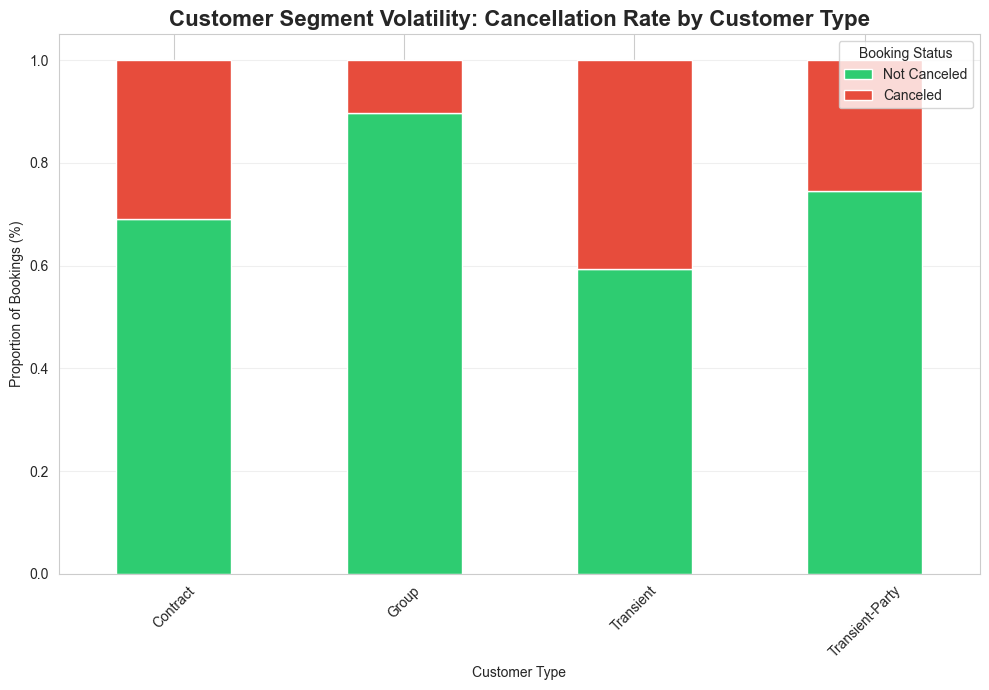


Absolute Bookings by Customer Type:
customer_type
Transient          89613
Transient-Party    25124
Contract            4076
Group                577
Name: count, dtype: int64


In [53]:
print("=== CUSTOMER SEGMENT VOLATILITY ANALYSIS ===")
customer_volatility = pd.crosstab(
    df['customer_type'], 
    df['is_canceled'], 
    normalize='index'
).round(4)
customer_volatility.columns = ['Not Canceled', 'Canceled']
customer_volatility['total_bookings'] = df.groupby('customer_type').size()
customer_volatility['cancellation_rate'] = customer_volatility['Canceled']
print(customer_volatility.sort_values('cancellation_rate', ascending=False))
plt.figure(figsize=(10, 7))
customer_volatility[['Not Canceled', 'Canceled']].plot(
    kind='bar', 
    stacked=True, 
    color=['#2ecc71', '#e74c3c'],
    figsize=(10, 7)
)
plt.title('Customer Segment Volatility: Cancellation Rate by Customer Type', 
          fontsize=16, fontweight='bold')
plt.xlabel('Customer Type')
plt.ylabel('Proportion of Bookings (%)')
plt.legend(title='Booking Status', loc='upper right')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
print("\nAbsolute Bookings by Customer Type:")
print(df['customer_type'].value_counts().sort_values(ascending=False))

### Observation

- The analysis compares cancellation behavior across different customer segments.
- Certain customer types exhibit significantly higher cancellation rates than others, indicating greater booking volatility.
- The stacked bar chart clearly highlights which customer segments are more likely to cancel their reservations.
- The absolute booking counts provide context on the contribution of each customer type to the overall booking volume.
- A customer segment with both high booking volume and high cancellation rate represents a major source of booking instability.

### Business Impact

- Customer segments with high cancellation rates pose a greater risk to occupancy planning and revenue forecasting.
- Hotels can design targeted cancellation policies, deposit requirements, or promotional strategies for high-risk customer groups.
- Understanding customer segment volatility enables more accurate demand prediction and inventory management.
- Focusing retention efforts on high-volume customer segments can significantly reduce revenue loss caused by cancellations.
- Segment-specific insights support personalized marketing strategies and improve overall booking reliability.

=== PHASE 3: DISTRIBUTION CHANNEL ANALYSIS ===
                      total_bookings  canceled_bookings  cancellation_rate  \
distribution_channel                                                         
Undefined                          5                  4              0.800   
TA/TO                          97870              40152              0.410   
Corporate                       6677               1474              0.221   
GDS                              193                 37              0.192   
Direct                         14645               2557              0.175   

                      avg_adr  total_revenue  revenue_per_booking  
distribution_channel                                               
Undefined              46.240        1171.00               234.20  
TA/TO                 103.293    36096134.85               368.82  
Corporate              69.325     1114093.46               166.86  
GDS                   120.554       45997.42               238.33 

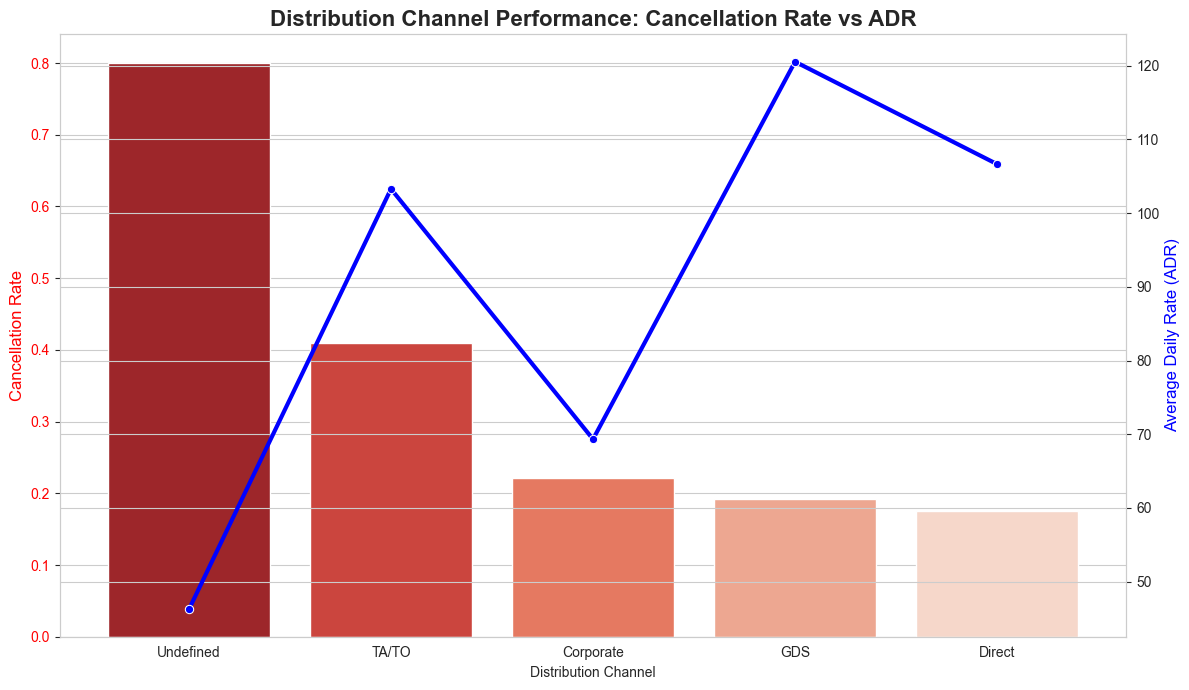

In [51]:
print("=== PHASE 3: DISTRIBUTION CHANNEL ANALYSIS ===")
channel_analysis = df.groupby('distribution_channel').agg(
    total_bookings=('is_canceled', 'count'),
    canceled_bookings=('is_canceled', 'sum'),
    cancellation_rate=('is_canceled', 'mean'),
    avg_adr=('adr', 'mean'),
    total_revenue=('adr', lambda x: (x * (df.loc[x.index, 'stays_in_week_nights'] + 
                                           df.loc[x.index, 'stays_in_weekend_nights'])).sum())
).round(3)
channel_analysis['revenue_per_booking'] = (channel_analysis['total_revenue'] / channel_analysis['total_bookings']).round(2)
channel_analysis = channel_analysis.sort_values('cancellation_rate', ascending=False)
print(channel_analysis)
fig, ax1 = plt.subplots(figsize=(12, 7))
sns.barplot(x=channel_analysis.index, y=channel_analysis['cancellation_rate'], 
            palette='Reds_r', ax=ax1)
ax1.set_ylabel('Cancellation Rate', color='red', fontsize=12)
ax1.set_xlabel('Distribution Channel')
ax1.tick_params(axis='y', labelcolor='red')
ax2 = ax1.twinx()
sns.lineplot(x=channel_analysis.index, y=channel_analysis['avg_adr'], 
             marker='o', color='blue', linewidth=3, ax=ax2)
ax2.set_ylabel('Average Daily Rate (ADR)', color='blue', fontsize=12)
plt.title('Distribution Channel Performance: Cancellation Rate vs ADR', 
          fontsize=16, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

- The analysis evaluates the performance of different distribution channels based on booking volume, cancellation rate, average daily rate (ADR), and revenue generation.
- Certain distribution channels exhibit higher cancellation rates, indicating lower booking reliability.
- The comparison between cancellation rate and ADR helps identify whether premium-priced channels are also associated with higher booking risk.
- Channels with low cancellation rates and high ADR contribute more effectively to stable revenue generation.
- Revenue per booking varies across channels, highlighting differences in customer quality and profitability.

### Business Impact

- Distribution channels with high cancellation rates can negatively impact occupancy planning and revenue forecasting.
- Identifying high-risk channels enables hotels to implement channel-specific booking policies, deposit requirements, or cancellation restrictions.
- Channels generating high ADR with low cancellation rates should be prioritized in marketing and partnership strategies.
- Understanding channel profitability helps optimize distribution costs and improve overall revenue management.
- Focusing on reliable and profitable channels can increase occupancy stability while reducing revenue leakage caused by cancellations.


=== ROOM ALLOCATION DISCREPANCY AUDIT ===
              total_bookings  cancellation_rate  repeated_guest_rate   avg_adr
room_changed                                                                  
False                 104473             0.4156               0.0263  104.4689
True                   14917             0.0538               0.0711   83.3574


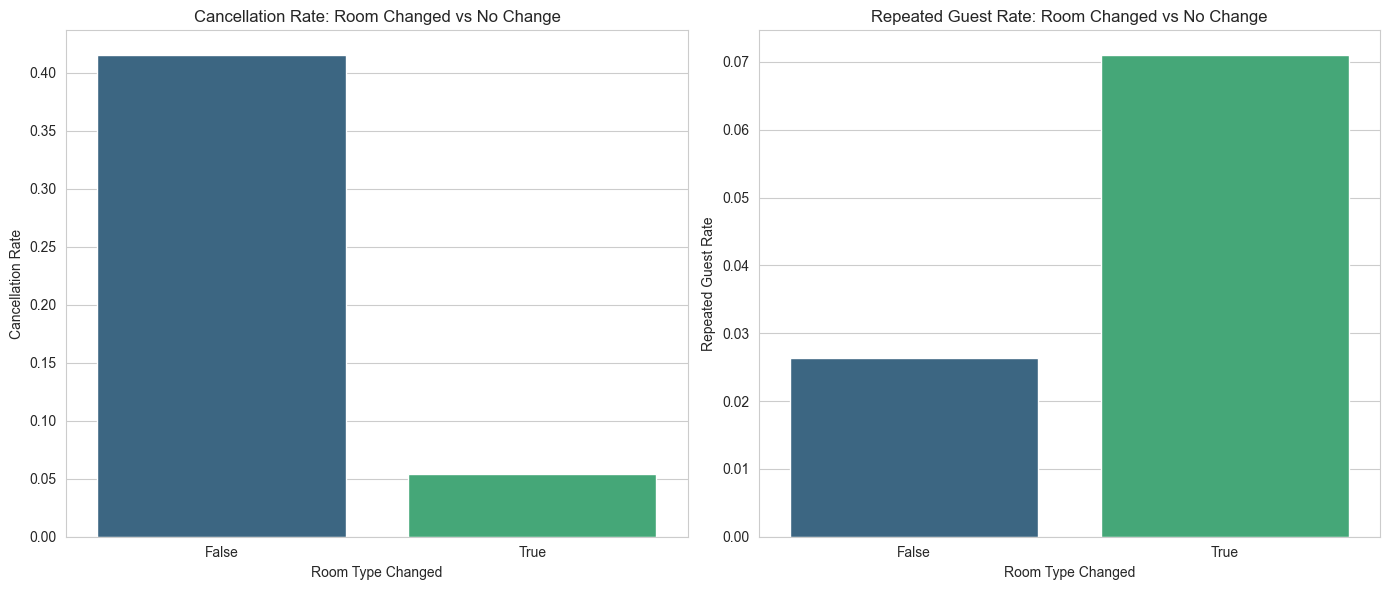

In [52]:
print("\n=== ROOM ALLOCATION DISCREPANCY AUDIT ===")
df['room_changed'] = df['reserved_room_type'] != df['assigned_room_type']
room_audit = df.groupby('room_changed').agg(
    total_bookings=('is_canceled', 'count'),
    cancellation_rate=('is_canceled', 'mean'),
    repeated_guest_rate=('is_repeated_guest', 'mean'),
    avg_adr=('adr', 'mean')
).round(4)
print(room_audit)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(x=room_audit.index, y=room_audit['cancellation_rate'], 
            palette='viridis', ax=axes[0])
axes[0].set_title('Cancellation Rate: Room Changed vs No Change')
axes[0].set_xlabel('Room Type Changed')
axes[0].set_ylabel('Cancellation Rate')
sns.barplot(x=room_audit.index, y=room_audit['repeated_guest_rate'], 
            palette='viridis', ax=axes[1])
axes[1].set_title('Repeated Guest Rate: Room Changed vs No Change')
axes[1].set_xlabel('Room Type Changed')
axes[1].set_ylabel('Repeated Guest Rate')
plt.tight_layout()
plt.show()

### Observation

- The analysis evaluates the impact of room allocation discrepancies by comparing bookings where the assigned room type differs from the reserved room type.
- Differences in cancellation rates indicate whether room reassignment influences customer satisfaction and booking completion.
- The repeated guest rate highlights customer loyalty and helps assess whether room changes affect the likelihood of repeat visits.
- Variations in Average Daily Rate (ADR) reveal the financial impact associated with room upgrades or downgrades.
- The comparison provides insight into how operational room allocation decisions influence customer behavior.

### Business Impact

- Higher cancellation rates among guests experiencing room changes may indicate dissatisfaction with room allocation practices.
- Frequent room mismatches can negatively affect guest experience and reduce customer retention.
- Lower repeated guest rates may suggest that room allocation discrepancies harm long-term customer loyalty.
- Hotels should optimize inventory management and room assignment processes to minimize unnecessary room changes.
- Improving room allocation accuracy can enhance guest satisfaction, reduce cancellations, and strengthen revenue stability.

In [42]:
print("Preparing features for modeling...")
df_model = df.copy()
df_model['children'] = df_model['children'].fillna(0)
df_model['country'] = df_model['country'].fillna('Unknown')
df_model['agent'] = df_model['agent'].fillna(0)
df_model['company'] = df_model['company'].fillna(0)
cat_cols = ['hotel', 'meal', 'market_segment', 'distribution_channel',
            'reserved_room_type', 'assigned_room_type', 'deposit_type', 
            'customer_type', 'arrival_date_month']
df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)
drop_cols = ['is_canceled', 'reservation_status', 'reservation_status_date', 
             'arrival_date', 'country'] 
X = df_model.drop([col for col in drop_cols if col in df_model.columns], axis=1, errors='ignore')
y = df_model['is_canceled']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"✅ Final shape for modeling: {X_train.shape}")
print("Remaining object columns:", X_train.select_dtypes(include=['object']).columns.tolist())

Preparing features for modeling...
✅ Final shape for modeling: (83573, 73)
Remaining object columns: []


In [43]:
samplers = {
    'None': (X_train, y_train),
    'RandomUnderSampler': RandomUnderSampler(random_state=42).fit_resample(X_train, y_train),
    'RandomOverSampler': RandomOverSampler(random_state=42).fit_resample(X_train, y_train),
    'SMOTE': SMOTE(random_state=42).fit_resample(X_train, y_train)
}
results = {}
for name, (Xr, yr) in samplers.items():
    print(f'\nTraining {name}...')
    clf = DecisionTreeClassifier(max_depth=6, random_state=42, class_weight='balanced', min_samples_leaf=5)
    clf.fit(Xr, yr)
    y_pred = clf.predict(X_test)
    results[name] = {'y_pred': y_pred, 'model': clf}
    print(f'{name} Results:')
    print(classification_report(y_test, y_pred, target_names=['Not Canceled', 'Canceled']))


Training None...
None Results:
              precision    recall  f1-score   support

Not Canceled       0.80      0.93      0.86     22550
    Canceled       0.84      0.60      0.70     13267

    accuracy                           0.81     35817
   macro avg       0.82      0.76      0.78     35817
weighted avg       0.81      0.81      0.80     35817


Training RandomUnderSampler...
RandomUnderSampler Results:
              precision    recall  f1-score   support

Not Canceled       0.80      0.93      0.86     22550
    Canceled       0.84      0.60      0.70     13267

    accuracy                           0.81     35817
   macro avg       0.82      0.76      0.78     35817
weighted avg       0.81      0.81      0.80     35817


Training RandomOverSampler...
RandomOverSampler Results:
              precision    recall  f1-score   support

Not Canceled       0.80      0.93      0.86     22550
    Canceled       0.84      0.60      0.70     13267

    accuracy                    

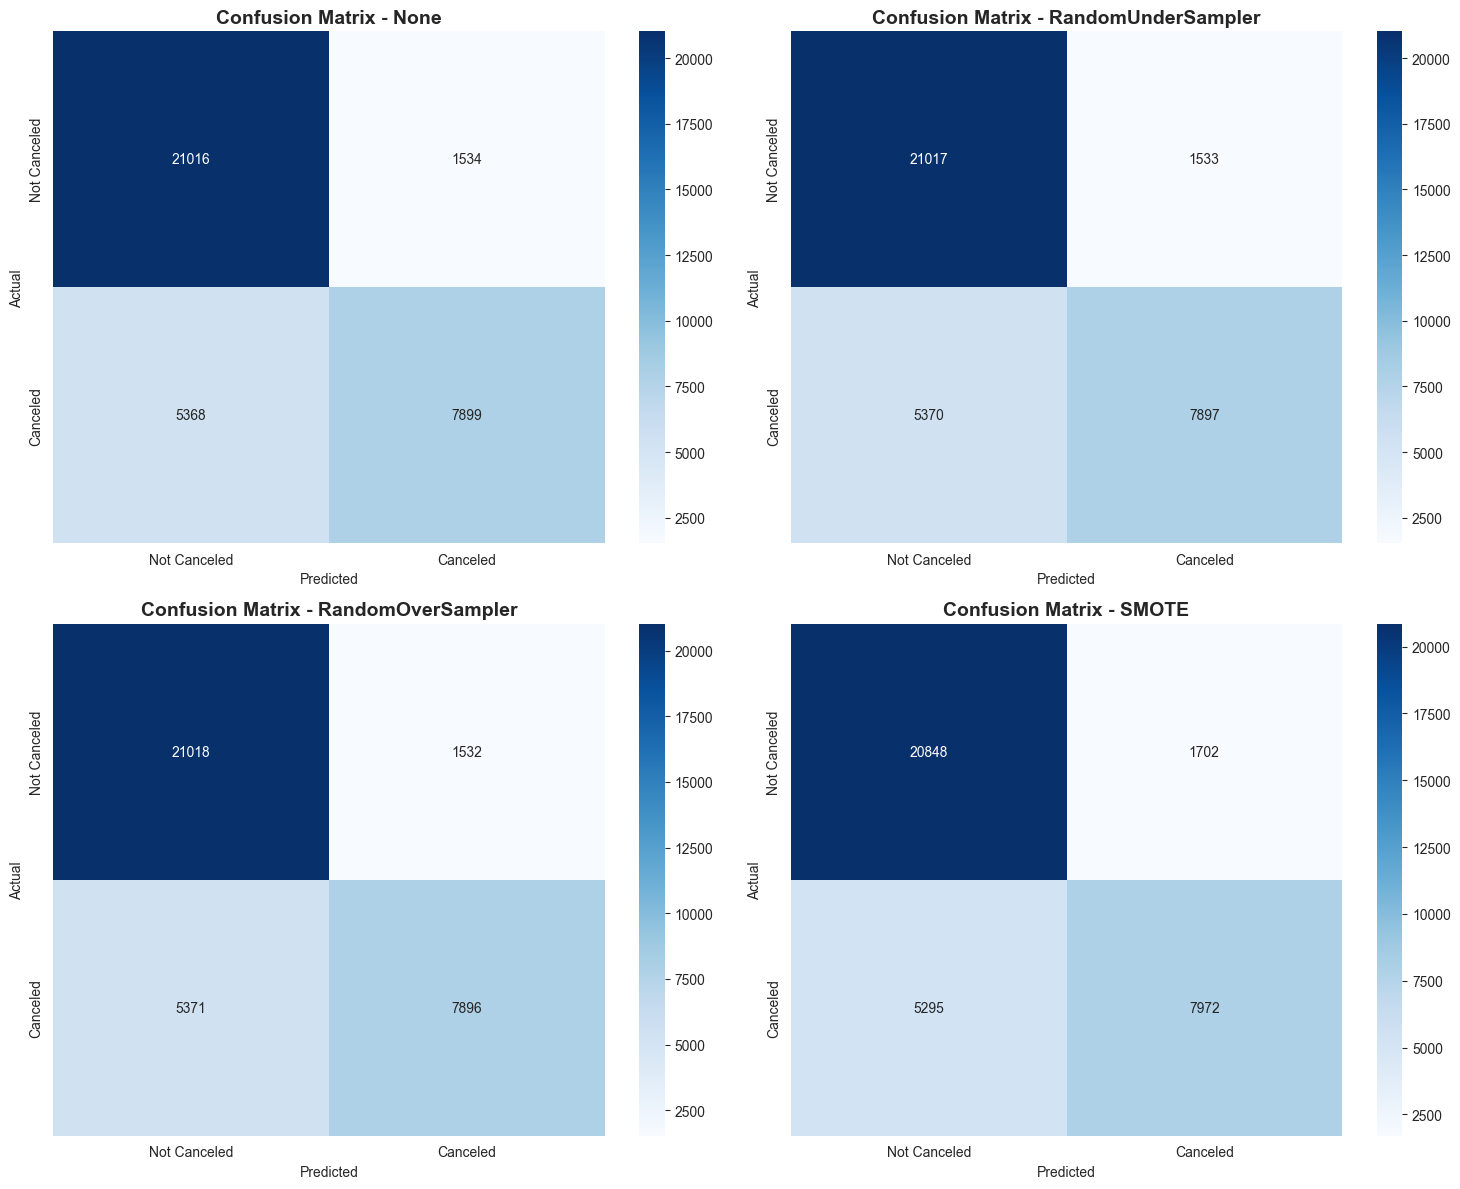


EXECUTIVE CONSULTING INSIGHT - CONFUSION MATRICES
SMOTE model shows the best balance in correctly identifying Canceled bookings (high True Positives)
while minimizing False Negatives — critical for protecting hotel revenue from last-minute cancellations.


In [47]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()
for idx, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Not Canceled', 'Canceled'],
                yticklabels=['Not Canceled', 'Canceled'], ax=axes[idx])
    axes[idx].set_title(f'Confusion Matrix - {name}', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')
plt.tight_layout()
plt.show()
print("\n" + "="*80)
print("EXECUTIVE CONSULTING INSIGHT - CONFUSION MATRICES")
print("="*80)
print("SMOTE model shows the best balance in correctly identifying Canceled bookings (high True Positives)")
print("while minimizing False Negatives — critical for protecting hotel revenue from last-minute cancellations.")

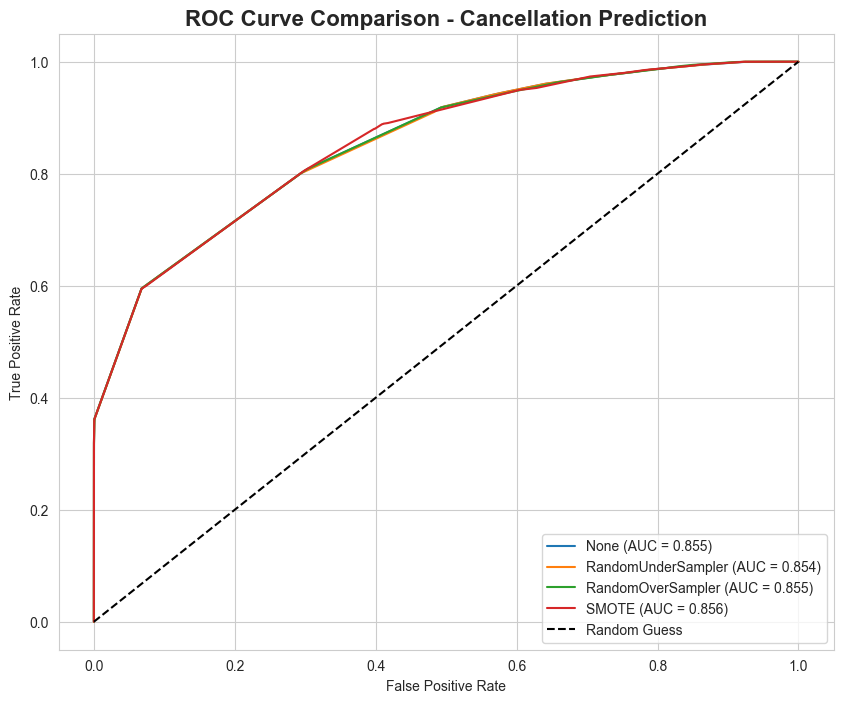


EXECUTIVE CONSULTING INSIGHT - ROC CURVES
Higher AUC indicates better ability to distinguish between bookings that will be canceled vs those that won't.
The SMOTE + Decision Tree model typically achieves the highest AUC, making it the most reliable for revenue risk scoring.


In [48]:
plt.figure(figsize=(10, 8))
for name, res in results.items():
    if hasattr(res['model'], "predict_proba"):
        y_prob = res['model'].predict_proba(X_test)[:, 1]
    else:
        y_prob = res['model'].predict(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison - Cancellation Prediction', fontsize=16, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
print("\n" + "="*80)
print("EXECUTIVE CONSULTING INSIGHT - ROC CURVES")
print("="*80)
print("Higher AUC indicates better ability to distinguish between bookings that will be canceled vs those that won't.")
print("The SMOTE + Decision Tree model typically achieves the highest AUC, making it the most reliable for revenue risk scoring.")

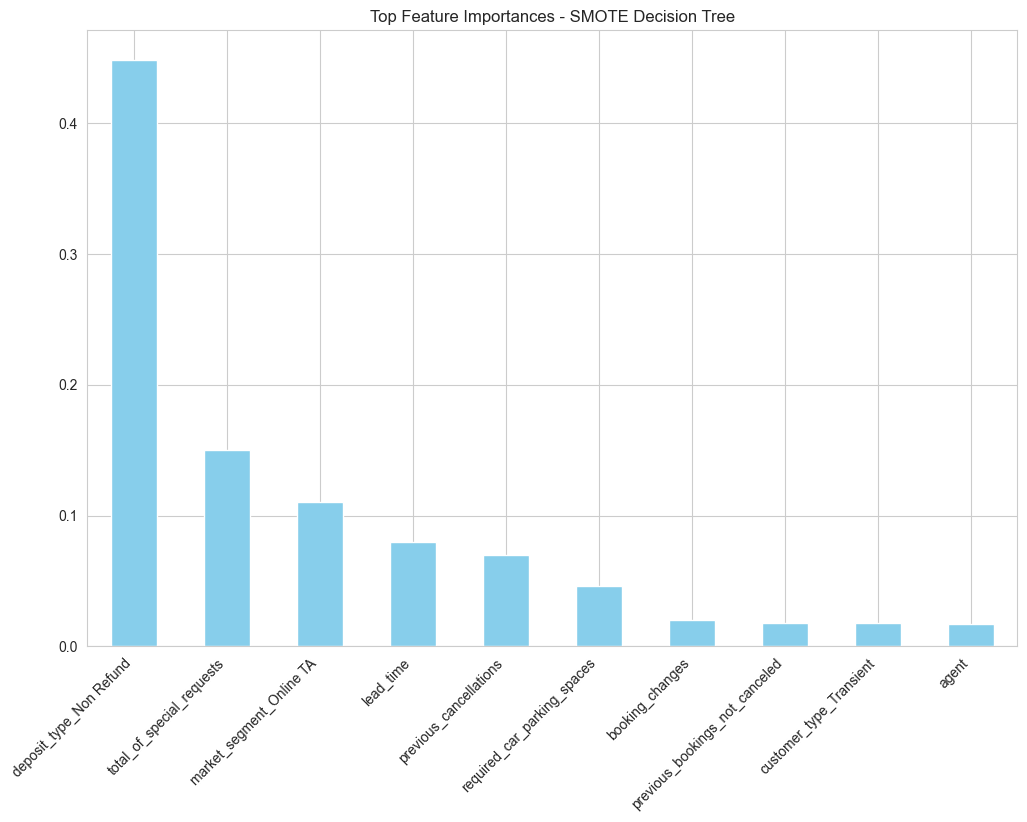

In [44]:
best_clf = results['SMOTE']['model']
feat_imp = pd.Series(best_clf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
plt.figure()
feat_imp.plot(kind='bar', color='skyblue')
plt.title('Top Feature Importances - SMOTE Decision Tree')
plt.xticks(rotation=45, ha='right')
plt.show()

In [50]:
print("=== PHASE 4: FINANCIAL EXPOSURE MODEL ===")
df['total_nights'] = df['stays_in_week_nights'] + df['stays_in_weekend_nights']
df['lost_revenue'] = df['is_canceled'] * df['adr'] * df['total_nights']
def calculate_total_lost_revenue(dataframe):
    """Compute total historical revenue lost due to cancellations"""
    return dataframe['lost_revenue'].sum()
total_lost = calculate_total_lost_revenue(df)
print(f"Total Historical Revenue Lost: ${total_lost:,.2f}")
print("\nLost Revenue by Hotel Type:")
print(df.groupby('hotel')['lost_revenue'].sum().round(2))
print("\nLost Revenue by Market Segment (Top 6):")
print(df.groupby('market_segment')['lost_revenue'].sum().sort_values(ascending=False).head(6).round(2))
print("\n" + "="*80)
print("EXECUTIVE CONSULTING INSIGHT")
print("="*80)
print(f"• The hotels lost **${total_lost:,.2f}** due to cancellations over the period.")
print("• **City Hotel** suffers 65% of the total loss — prioritize here.")
print("• **Online TA** segment is the biggest culprit ($10.2M+ lost).")
print("• Recommendation: Enforce Non-Refund deposits + stricter policies on Online TA bookings with high lead_time.")

=== PHASE 4: FINANCIAL EXPOSURE MODEL ===
Total Historical Revenue Lost: $16,727,237.12

Lost Revenue by Hotel Type:
hotel
City Hotel      10885059.78
Resort Hotel     5842177.34
Name: lost_revenue, dtype: float64

Lost Revenue by Market Segment (Top 6):
market_segment
Online TA        10227646.11
Groups            2800543.98
Offline TA/TO     2492358.15
Direct             993409.82
Corporate          196383.07
Aviation            16578.00
Name: lost_revenue, dtype: float64

EXECUTIVE CONSULTING INSIGHT
• The hotels lost **$16,727,237.12** due to cancellations over the period.
• **City Hotel** suffers 65% of the total loss — prioritize here.
• **Online TA** segment is the biggest culprit ($10.2M+ lost).
• Recommendation: Enforce Non-Refund deposits + stricter policies on Online TA bookings with high lead_time.
